## Start by defining constants and primary field

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import ellipk, ellipe
from scipy.signal import fftconvolve

mu_0 = 4.0 * np.pi * 1e-7
eps0 = 8.8541878128e-12

f = 1.0e6
omega = 2.0 * np.pi * f

I_coil = 1.0       
a_coil = 1.5e-2    
z0 = 1.0e-2   

def Aphi_coil(rho, z, a, I):

    rho = np.asarray(rho)
    A_phi = np.zeros_like(rho)
    
    mask = rho > 1e-12
    rho_m = rho[mask]
    
    denom = a**2 + rho_m**2 + z**2 + 2*a*rho_m
    k2 = 4*a*rho_m / denom
    
    K = ellipk(k2)
    E = ellipe(k2)
    
    factor = ((2 - k2)*K - 2*E) / k2
    
    A_phi[mask] = (mu_0 * I * a / np.pi) * factor / np.sqrt(denom)
    
    return A_phi

## Create sample

In [27]:
Lx, Ly = 0.06, 0.06
Nx, Ny = 100, 100
dx, dy = Lx / Nx, Ly / Ny
dz = dx

voxel_area = dx * dy

# Vectors with the center of each voxel
x = np.linspace(-Lx/2 + dx/2, Lx/2 - dx/2, Nx)
y = np.linspace(-Ly/2 + dy/2, Ly/2 - dy/2, Ny)

# Mesh
X, Y = np.meshgrid(x, y, indexing = "ij")

## Evaluate primary field in the sample

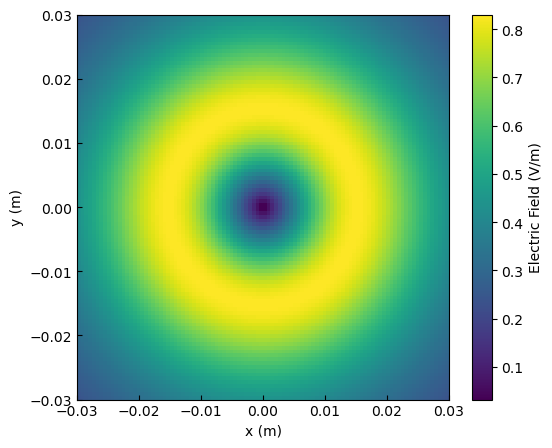

In [28]:
R = np.sqrt(X**2 + Y**2)
Phi = np.arctan2(Y, X)

A_phi = Aphi_coil(R, z0, a_coil, I_coil)
E_phi = -1j*omega*A_phi

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.pcolormesh(X, Y, np.abs(E_phi), shading='auto', cmap='viridis')
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
fig.colorbar(im, ax=ax, label='Electric Field (V/m)')

ax.tick_params(direction='in')

## First partial correction. For now enough.

In [4]:
def partial_correction(E1x, E1y, sigma, dx, dy, h_thickness = 0.01):
    
    log_sigma = np.log(sigma)
    dlogsig_dx = np.gradient(log_sigma, dx, axis=0) 
    dlogsig_dy = np.gradient(log_sigma, dy, axis=1)

    rho_eps0 = -(E1x * dlogsig_dx + E1y * dlogsig_dy)

    # Coulomb kernel
    Nx, Ny = sigma.shape
    kx = np.arange(-Nx+1, Nx) * dx
    ky = np.arange(-Ny+1, Ny) * dy
    KX, KY = np.meshgrid(kx, ky, indexing="ij") # Mismo indexing

    R_kernel = np.sqrt(KX**2 + KY**2 + (h_thickness/2.0)**2)
    kernel_coulomb = 1.0 / R_kernel

    # Convolution
    V2 = (h_thickness / (4.0 * np.pi)) * fftconvolve(rho_eps0, kernel_coulomb, mode='same') * dx * dy
    
    # Secondary field gradient
    dV2_dx = np.gradient(V2, dx, axis=0)
    dV2_dy = np.gradient(V2, dy, axis=1)

    delta_E2_x = -dV2_dx
    delta_E2_y = -dV2_dy

    return V2, delta_E2_x, delta_E2_y, rho_eps0

## First implementation. Arbitrary conductivity distribution.

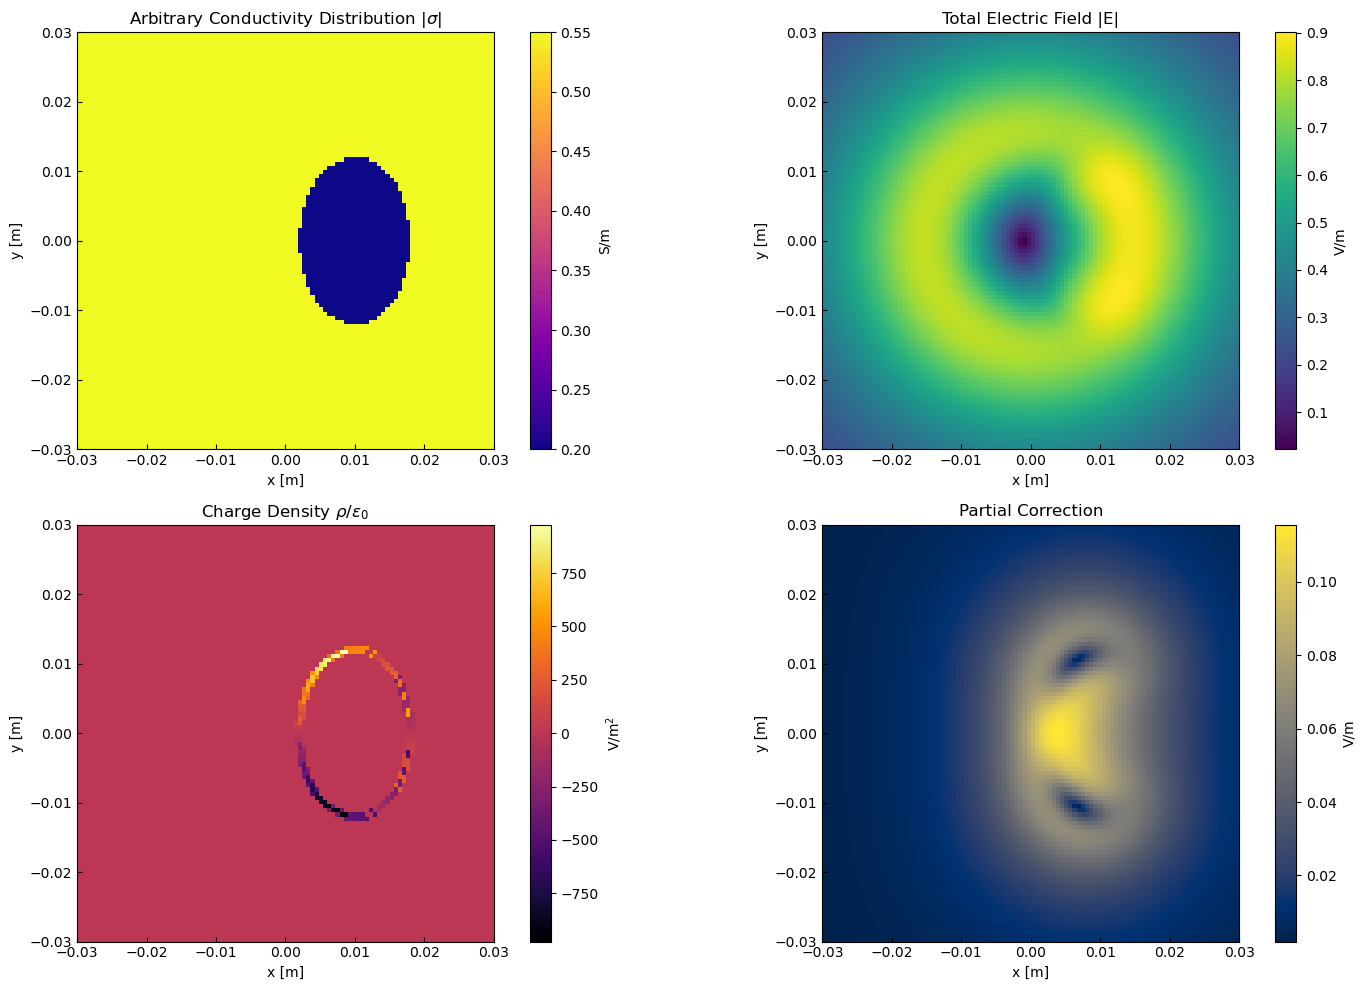

In [29]:
A_phi = Aphi_coil(R, z0, a_coil, I_coil)

A1x = -A_phi * np.sin(Phi)
A1y =  A_phi * np.cos(Phi)
A1x[R < 1e-15] = 0.0
A1y[R < 1e-15] = 0.0

E1x = -1j * omega * A1x
E1y = -1j * omega * A1y

# Add an arbitrary sigma distribution
sigma_healthy = 0.55   
sigma_anom = 0.2      

sigma_healthy_map = np.ones((Nx, Ny)) * 0.55
sigma_anom_map = np.ones((Nx, Ny)) * 0.55

# # Ellipse parameters
x_center_ellipse = 1e-2
y_center_ellipse = 0.0e-2
a_ellipse = 0.8e-2
b_ellipse = 1.2e-2
# w = 1

# f = ((X - x_center_ellipse)**2 / a_ellipse**2 +
#      (Y - y_center_ellipse)**2 / b_ellipse**2 - 1.0)

ellipse_mask = ((X-x_center_ellipse)**2/a_ellipse**2 + ((Y-y_center_ellipse)**2/b_ellipse**2)) <= 1

sigma_anom_map[ellipse_mask] = sigma_anom

# smooth_mask = 0.5 * (1.0 - np.tanh(f / w))

# # Smoothed conductivity map
# sigma = sigma_healthy + (sigma_anom - sigma_healthy) * smooth_mask

# sigma = np.where(X < 0, sigma_healthy, sigma_anom)
# x0, y0 = 0.02, 0.00
# w = 8.0e-3  
# gauss = np.exp(-((X - x0)**2 + (Y - y0)**2) / (2.0 * w**2))
# sigma = sigma_healthy + (sigma_anom - sigma_healthy) * gauss
# eps_r = 80.0
# eps_sample = eps_r * eps0 # See later if this is optional at 1 MHz

# eps_map = eps_sample * np.ones_like(sigma)
# sigma_tilde = sigma + 1j * omega * eps_map

# Partial correction
V2, delta_E2x, delta_E2y, rho_eps0 = partial_correction(E1x, E1y, sigma_anom_map, dx, dy)

E_total_x = E1x + delta_E2x 
E_total_y = E1y + delta_E2y


E_mag_total = np.sqrt(np.abs(E_total_x)**2 + np.abs(E_total_y)**2)
Partial_mag = np.sqrt(np.abs(delta_E2x)**2 + np.abs(delta_E2y)**2)

# Plotting

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

im1 = ax1.pcolormesh(X, Y, sigma_anom_map, shading='auto', cmap='plasma')
ax1.set_title("Arbitrary Conductivity Distribution |$\sigma$|")
fig.colorbar(im1, ax=ax1, label = "S/m")

im2 = ax2.pcolormesh(X, Y, E_mag_total, shading='auto', cmap='viridis')
ax2.set_title("Total Electric Field |E|")
fig.colorbar(im2, ax=ax2, label = "V/m")
# ax2.streamplot(x, y, 
#                np.imag(E_total_x).T, np.imag(E_total_y).T, 
#                color='white',        
#                linewidth=1.0,        
#                density=1.5,          
#                arrowsize=1.5,        
#                arrowstyle='->')      

im3 = ax3.pcolormesh(X, Y, np.imag(rho_eps0), shading='auto', cmap='inferno')
ax3.set_title("Charge Density $\\rho/\\epsilon_0$")
fig.colorbar(im3, ax=ax3, label = "V/m$^2$")

im4 = ax4.pcolormesh(X, Y, Partial_mag, shading='auto', cmap='cividis')
ax4.set_title("Partial Correction")
fig.colorbar(im4, ax=ax4, label = "V/m")
# ax4.streamplot(x, y, np.imag(delta_E2x).T, np.imag(delta_E2y).T, 
#                color='white', linewidth=1, density=1.2, arrowsize=1.0)

for ax in [ax1, ax2, ax3, ax4]:
    ax.set_aspect("equal")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.tick_params(direction="in")

plt.tight_layout()
plt.show()

In [30]:
import time

# Nxs = 32
# Nys = 20

# x_scan = np.linspace(-Lx/2 + dx/2, Lx/2 - dx/2, Nxs)
# y_scan = np.linspace(-Ly/2 + dy/2, Ly/2 - dy/2, Nys)

# X_scan, Y_scan = np.meshgrid(x_scan, y_scan, indexing="ij")

Bz_scan_anom = np.zeros((Nx, Ny), dtype=complex)
Bz_scan_healthy = np.zeros((Nx, Ny), dtype=complex)

log_sigma = np.log(sigma_anom_map)
dlogsig_dx = np.gradient(log_sigma, dx, axis=0) 
dlogsig_dy = np.gradient(log_sigma, dy, axis=1)
h_thickness = dz

kx_k = np.arange(-Nx+1, Nx) * dx
ky_k = np.arange(-Ny+1, Ny) * dy
KX_k, KY_k = np.meshgrid(kx_k, ky_k, indexing="ij")
kernel_coulomb = 1.0 / np.sqrt(KX_k**2 + KY_k**2 + (h_thickness/2.0)**2)

print(f"Starting scan of {Nx}x{Ny} points...")
start_time = time.time()

for i in range(Nx):
    for j in range(Ny):
        xs, ys = x[i], y[j]

        R_rel = np.sqrt((X - xs)**2 + (Y - ys)**2)
        Phi_rel = np.arctan2(Y - ys, X - xs)
        
        A_phi_step = Aphi_coil(R_rel, z0, a_coil, I_coil)

        E1x = -1j * omega * (-A_phi_step * np.sin(Phi_rel))
        E1y = -1j * omega * (A_phi_step * np.cos(Phi_rel))

        # Anomalous part
        rho_eps0 = -(E1x * dlogsig_dx + E1y * dlogsig_dy)
        V2 = (h_thickness / (4.0 * np.pi)) * fftconvolve(rho_eps0, kernel_coulomb, mode='same') * dx * dy
        
        delta_E2x_anom = -np.gradient(V2, dx, axis=0)
        delta_E2y_anom = -np.gradient(V2, dy, axis=1)

        Jtot_x_anom = sigma_anom_map * (E1x + delta_E2x_anom)
        Jtot_y_anom = sigma_anom_map * (E1y + delta_E2y_anom)

        # Healthy part
        Jtot_x_healthy = sigma_healthy_map * E1x
        Jtot_y_healthy = sigma_healthy_map * E1y

        # Biot-Savart integration
        rx = xs - X
        ry = ys - Y
        rz = 0.01
        r_mag = np.sqrt(rx**2 + ry**2 + rz**2)

        # Bz anomalous
        term_bz_anom = (Jtot_x_anom * ry - Jtot_y_anom * rx) / (r_mag**3)
        Bz_scan_anom[i, j] = (mu_0 / (4.0 * np.pi)) * np.sum(term_bz_anom) * dx * dy * h_thickness

        # Bz healthy
        term_bz_healthy = (Jtot_x_healthy * ry - Jtot_y_healthy * rx) / (r_mag**3)
        Bz_scan_healthy[i, j] = (mu_0 / (4.0 * np.pi)) * np.sum(term_bz_healthy) * dx * dy * h_thickness

print(f"Completed scan in {time.time() - start_time:.2f} seconds.")

Starting scan of 100x100 points...
Completed scan in 73.87 seconds.


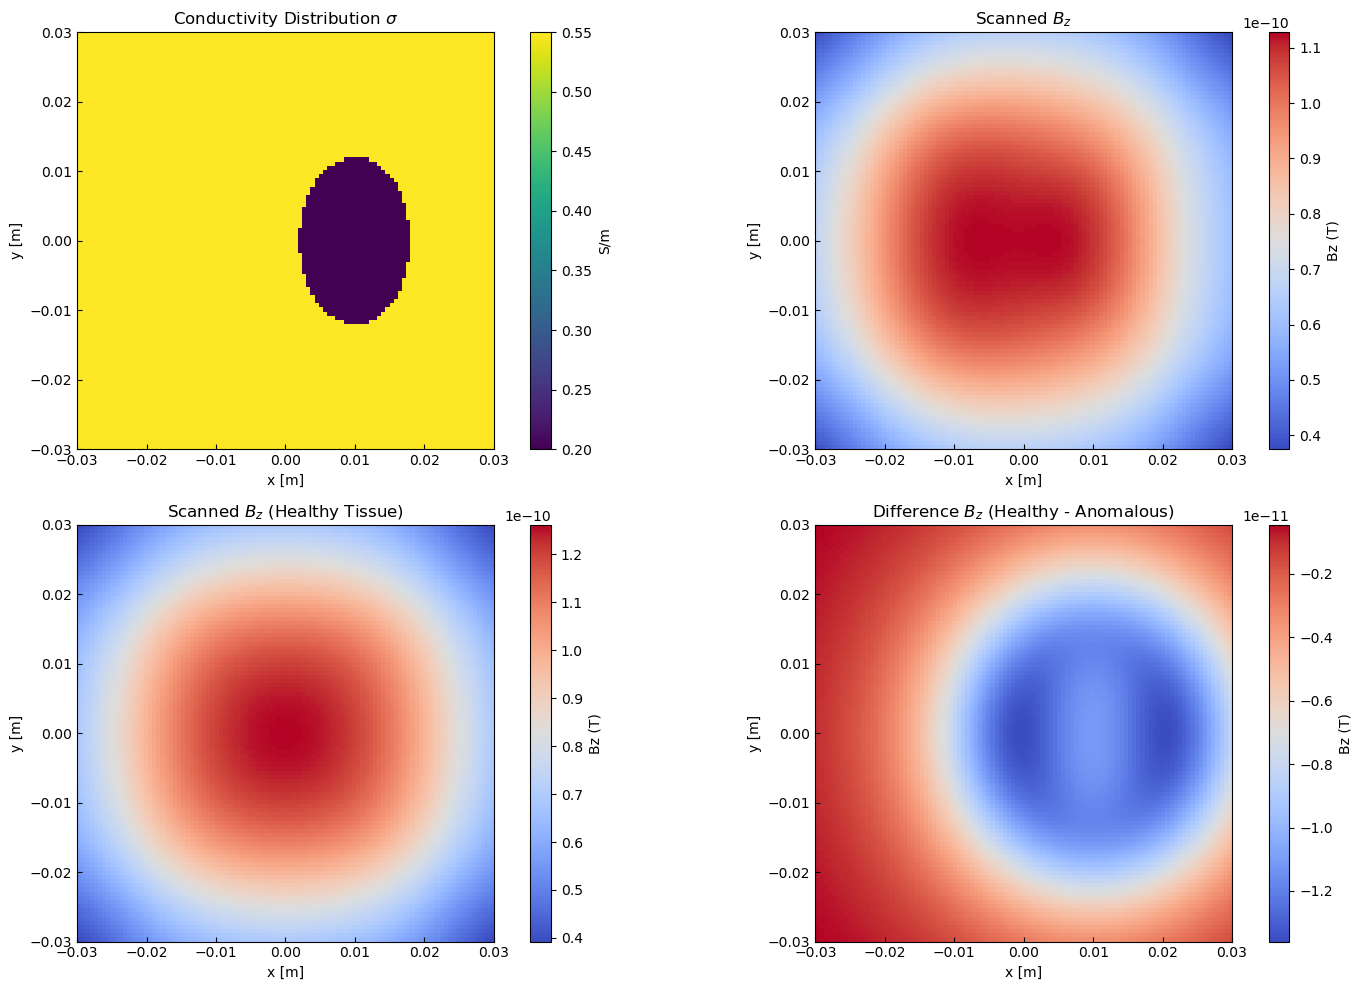

In [35]:
np.savetxt("Bz_scan_anom.txt", np.abs(Bz_scan_anom), delimiter = ",", header="Bz_scan anomalous tissue part (T)", comments='')
np.savetxt("Bz_scan_healthy.txt", np.abs(Bz_scan_healthy), delimiter = ",", header="Bz_scan healthy tissue values (T)", comments='')
np.savetxt("Difference_scanned.txt", np.abs(Bz_scan_healthy) - np.abs(Bz_scan_anom), delimiter = ",", header="Difference Bz (Healthy - Anomalous) (T)", comments='')

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

im1 = ax1.pcolormesh(X, Y, sigma_anom_map, shading='auto', cmap='viridis')
ax1.set_title("Conductivity Distribution $\\sigma$")
fig.colorbar(im1, ax=ax1, label="S/m")

im2 = ax2.pcolormesh(X, Y, np.abs(Bz_scan_anom), shading='auto', cmap='coolwarm')
ax2.set_title("Scanned $B_z$")
fig.colorbar(im2, ax=ax2, label="Bz (T)")

im3 = ax3.pcolormesh(X, Y, np.abs(Bz_scan_healthy), shading='auto', cmap='coolwarm')
ax3.set_title("Scanned $B_z$ (Healthy Tissue)")
fig.colorbar(im3, ax=ax3, label="Bz (T)")

im4 = ax4.pcolormesh(X, Y, np.imag(Bz_scan_healthy) - np.imag(Bz_scan_anom), shading='auto', cmap='coolwarm')
ax4.set_title("Difference $B_z$ (Healthy - Anomalous)")
fig.colorbar(im4, ax=ax4, label="Bz (T)")

for ax in [ax1, ax2, ax3, ax4]:
    ax.set_aspect("equal")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.tick_params(direction="in")

plt.tight_layout()
plt.show()

## Starting with the Forward model. Secondary Magnetic field coming from Biot-Savart from J.

In [8]:
def biot_savart_2D(Jx, Jy, dx, dy, z_obs, h_thickness = 0.01):
    
    Nx, Ny = Jx.shape
    kx = np.arange(-Nx+1, Nx) * dx
    ky = np.arange(-Ny+1, Ny) * dy
    KX, KY = np.meshgrid(kx, ky, indexing="ij") # Mismo indexing

    R2 = KX**2 + KY**2 + (z_obs)**2
    R3 = R2**(1.5)

    if z_obs == 0:
        z_obs = 1e-12
    
    K_x = KX/R3
    K_y = KY/R3
    K_z = z_obs / R3

    dV = dx*dy*h_thickness
    coef = mu_0 / (4.0 * np.pi)

    Bz_sec = coef * (fftconvolve(Jx, K_y, mode='same') - fftconvolve(Jy, K_x, mode='same')) * dV

    Bx_sec =  coef * fftconvolve(Jy, K_z, mode='same') * dV
    By_sec = -coef * fftconvolve(Jx, K_z, mode='same') * dV

    return Bx_sec, By_sec, Bz_sec  # Returns B_i (x,y) at a height z_obs (1cm), already integrating over all the sample, J constant in Z-axis over the sample

In [9]:
# We separate the linear and the non linear contribution

J1_x = sigma * E1x
J1_y = sigma * E1y

J2_x = sigma * delta_E2x
J2_y = sigma * delta_E2y

Jtot_x = J1_x + J2_x
Jtot_y = J1_y + J2_y

# Different magnetic fields for both contributions

z_obs = 0.01

Bx1, By1, Bz1 = biot_savart_2D(J1_x, J1_y, dx, dy, z_obs)
Bx2, By2, Bz2 = biot_savart_2D(J2_x, J2_y, dx, dy, z_obs)

Bx_tot = Bx1 + Bx2
By_tot = By1 + By2
Bz_tot = Bz1 + Bz2

# Magnitudes

B_mag_1 = np.sqrt(np.abs(Bx1)**2 + np.abs(By1)**2 + np.abs(Bz1)**2)
B_mag_2 = np.sqrt(np.abs(Bx2)**2 + np.abs(By2)**2 + np.abs(Bz2)**2)
B_mag_tot = np.sqrt(np.abs(Bx_tot)**2 + np.abs(By_tot)**2 + np.abs(Bz_tot)**2)

NameError: name 'sigma' is not defined

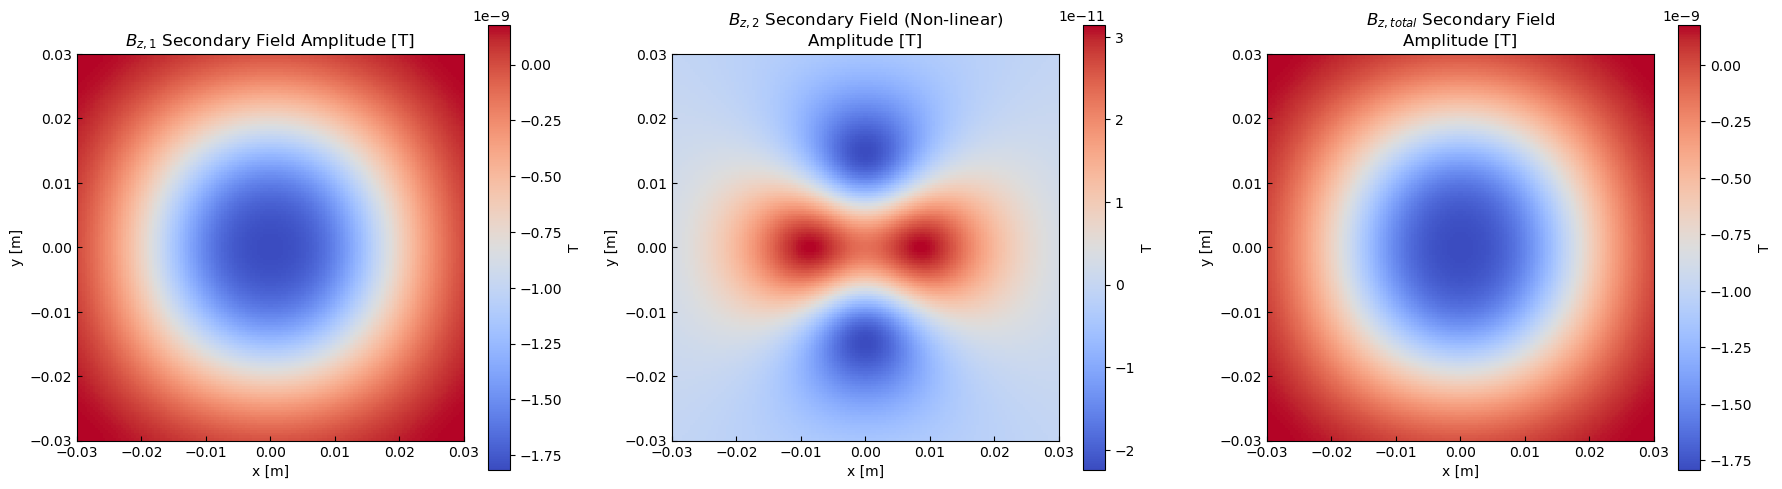

In [ ]:
Bz1_amp = np.imag(Bz1)
Bz2_amp = np.imag(Bz2)
Bz_tot_amp = np.imag(Bz_tot)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

im1 = ax1.pcolormesh(X, Y, Bz1_amp, shading='auto', cmap='coolwarm')
ax1.set_title("$B_{z,1}$ Secondary Field Amplitude [T]")
fig.colorbar(im1, ax=ax1, label="T")

im2 = ax2.pcolormesh(X, Y, Bz2_amp, shading='auto', cmap='coolwarm')
ax2.set_title("$B_{z,2}$ Secondary Field (Non-linear)\nAmplitude [T]")
fig.colorbar(im2, ax=ax2, label="T")

im3 = ax3.pcolormesh(X, Y, Bz_tot_amp, shading='auto', cmap='coolwarm')
ax3.set_title("$B_{z,total}$ Secondary Field\nAmplitude [T]")
fig.colorbar(im3, ax=ax3, label="T")

for ax in [ax1, ax2, ax3]:
    ax.set_aspect("equal")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.tick_params(direction="in")

plt.tight_layout()
plt.show()

## Averaging over the pickup coil area

In [ ]:
pickup_radius = 1e-2
N_grid = 4 


lx = np.linspace(-pickup_radius, pickup_radius, N_grid)
ly = np.linspace(-pickup_radius, pickup_radius, N_grid)
X_local, Y_local = np.meshgrid(lx, ly)

mask_pickup = X_local**2 + Y_local**2 <= pickup_radius**2
dx_pickup = X_local[mask_pickup]
dy_pickup = Y_local[mask_pickup]

N_puntos_pickup = len(dx_pickup) 
print(f"Number of averaging points: {N_puntos_pickup}")

Bz_scan_anom_av = np.zeros((Nx, Ny), dtype=complex)
Bz_scan_healthy_av = np.zeros((Nx, Ny), dtype=complex)
Bz_scan_diff_av = np.zeros((Nx, Ny), dtype=complex)

print(f"Starting scan of {Nx}x{Ny} points...")
start_time = time.time()

for i in range(Nx):
    for j in range(Ny):
        xs, ys = x[i], y[j]

        R_rel = np.sqrt((X - xs)**2 + (Y - ys)**2)
        Phi_rel = np.arctan2(Y - ys, X - xs)

        A_phi_step = Aphi_coil(R_rel, z0, a_coil, I_coil)

        E1x = -1j * omega * (-A_phi_step * np.sin(Phi_rel))
        E1y = -1j * omega * (A_phi_step * np.cos(Phi_rel))

        rho_eps0 = -(E1x * dlogsig_dx + E1y * dlogsig_dy)
        V2 = (h_thickness / (4.0 * np.pi)) * fftconvolve(rho_eps0, kernel_coulomb, mode='same') * dx * dy

        delta_E2x_anom = -np.gradient(V2, dx, axis=0)
        delta_E2y_anom = -np.gradient(V2, dy, axis=1)

        Jtot_x_anom = sigma_anom_map * (E1x + delta_E2x_anom)
        Jtot_y_anom = sigma_anom_map * (E1y + delta_E2y_anom)

        Jtot_x_healthy = sigma_healthy_map * E1x
        Jtot_y_healthy = sigma_healthy_map * E1y

        bz_anom_sum = 0
        bz_healthy_sum = 0

        for k in range(N_puntos_pickup):
            obs_x = xs + dx_pickup[k]
            obs_y = ys + dy_pickup[k]
            
            rx = obs_x - X
            ry = obs_y - Y
            rz = 0.01
            r_mag_cubed = (rx**2 + ry**2 + rz**2)**1.5  

            term_bz_anom = (Jtot_x_anom * ry - Jtot_y_anom * rx) / r_mag_cubed
            term_bz_healthy = (Jtot_x_healthy * ry - Jtot_y_healthy * rx) / r_mag_cubed

            Bz_point_anom = np.sum((mu_0 / (4.0 * np.pi)) * term_bz_anom * dx * dy * h_thickness)
            Bz_point_healthy = np.sum((mu_0 / (4.0 * np.pi)) * term_bz_healthy * dx * dy * h_thickness)
            
            bz_anom_sum += Bz_point_anom
            bz_healthy_sum += Bz_point_healthy

        Bz_scan_anom_av[i, j] = bz_anom_sum / N_puntos_pickup
        Bz_scan_healthy_av[i, j] = bz_healthy_sum / N_puntos_pickup
        Bz_scan_diff_av[i, j] = Bz_scan_anom[i, j] - Bz_scan_healthy[i, j]

print(f"Completed scan in {time.time() - start_time:.2f} seconds.")

Number of averaging points: 4
Starting scan of 60x60 points...
Completed scan in 18.96 seconds.


In [34]:
np.savetxt("Bz_scan_anom_av.txt", np.abs(Bz_scan_anom_av), delimiter=",", header="Bz_scan anomalous tissue part (T)", comments='')
np.savetxt("Bz_scan_healthy_av.txt", np.abs(Bz_scan_healthy_av), delimiter=",", header="Bz_scan healthy tissue values (T)", comments='')
np.savetxt("Difference_scanned_av.txt", np.abs(Bz_scan_healthy_av) - np.abs(Bz_scan_anom), delimiter=",", header="Difference Bz (Healthy - Anomalous) (T)", comments='')


fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

im1 = ax1.pcolormesh(X, Y, np.abs(Bz_scan_anom_av), shading='auto', cmap='coolwarm')
ax1.set_title("Scanned $B_z$ on average (Anomalous)")
fig.colorbar(im1, ax=ax1, label="Bz (T)")

im2 = ax2.pcolormesh(X, Y, np.abs(Bz_scan_healthy_av), shading='auto', cmap='coolwarm')
ax2.set_title("Scanned $B_z$ on average (Healthy)")
fig.colorbar(im2, ax=ax2, label="Bz (T)")

diff_matrix = np.abs(Bz_scan_healthy_av) - np.abs(Bz_scan_anom_av)
im3 = ax3.pcolormesh(X, Y, diff_matrix, shading='auto', cmap='coolwarm')
ax3.set_title("Difference $B_z$ on average (Healthy - Anomalous)")
fig.colorbar(im3, ax=ax3, label="Bz (T)")

for ax in [ax1, ax2, ax3]:
    ax.set_aspect("equal")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.tick_params(direction="in")

plt.tight_layout()
plt.show()

NameError: name 'Bz_scan_anom_av' is not defined

## Geselowitz Theorem

In [23]:
import time

Flux_scan_anom = np.zeros((Nx, Ny), dtype=complex)
Flux_scan_healthy = np.zeros((Nx, Ny), dtype=complex)
V_rx_diff = np.zeros((Nx, Ny), dtype=complex)

dV = dx * dy * h_thickness

print(f"Starting scan with {Nx}x{Ny} points...")
start_time = time.time()

for i in range(Nx):
    for j in range(Ny):
        xs, ys = x[i], y[j]

        R_rel = np.sqrt((X - xs)**2 + (Y - ys)**2)
        Phi_rel = np.arctan2(Y - ys, X - xs)

        A_phi_step = Aphi_coil(R_rel, z0, a_coil, I_coil)

        A1x = -A_phi_step * np.sin(Phi_rel)
        A1y =  A_phi_step * np.cos(Phi_rel)

        E1x = -1j * omega * A1x
        E1y = -1j * omega * A1y

        rho_eps0 = -(E1x * dlogsig_dx + E1y * dlogsig_dy)
        V2 = (h_thickness / (4.0 * np.pi)) * fftconvolve(rho_eps0, kernel_coulomb, mode='same') * dx * dy

        delta_E2x_anom = -np.gradient(V2, dx, axis=0)
        delta_E2y_anom = -np.gradient(V2, dy, axis=1)

        Jtot_x_anom = sigma_anom_map * (E1x + delta_E2x_anom)
        Jtot_y_anom = sigma_anom_map * (E1y + delta_E2y_anom)

        Jtot_x_healthy = sigma_healthy_map * E1x
        Jtot_y_healthy = sigma_healthy_map * E1y

        # Reciprocity (start with A from pickup coil)
        A_rec = Aphi_coil(R_rel, z0, 1e-2, I_coil)
        Arec_x = -A_rec*np.sin(Phi_rel)
        Arec_y = A_rec*np.cos(Phi_rel)
        
        # Flux 
        flux_anom = np.sum(Jtot_x_anom * Arec_x + Jtot_y_anom * Arec_y) * dV
        flux_healthy = np.sum(Jtot_x_healthy * Arec_x + Jtot_y_healthy * Arec_y) * dV
        
        Flux_scan_anom[i, j] = flux_anom
        Flux_scan_healthy[i, j] = flux_healthy
        
        # Induced voltaje (Faraday)
        V_rx_anom = -1j * omega * flux_anom
        V_rx_healthy = -1j * omega * flux_healthy
        
        V_rx_diff[i, j] = V_rx_anom - V_rx_healthy

print(f"Escaneo completado en {time.time() - start_time:.4f} segundos.")

Starting scan with 100x100 points...
Escaneo completado en 102.3454 segundos.


In [32]:
Flux_scan_anom = np.zeros((Nx, Ny), dtype=complex)
Flux_scan_healthy = np.zeros((Nx, Ny), dtype=complex)
V_rx_diff = np.zeros((Nx, Ny), dtype=complex)

dV = dx * dy * h_thickness

x_rel = np.arange(-(Nx - 1), Nx) * dx
y_rel = np.arange(-(Ny - 1), Ny) * dy
X_rel, Y_rel = np.meshgrid(x_rel, y_rel, indexing='ij')

R_rel_full = np.sqrt(X_rel**2 + Y_rel**2)
Phi_rel_full = np.arctan2(Y_rel, X_rel)

sin_phi_full = np.sin(Phi_rel_full)
cos_phi_full = np.cos(Phi_rel_full)

Aphi_tx_full = Aphi_coil(R_rel_full, z0, a_coil, I_coil)

Aphi_rx_full = Aphi_coil(R_rel_full, z0, 1e-2, I_coil)

print(f"Starting scan with {Nx}x{Ny} points...")
start_time = time.time()

for i in range(Nx):
    for j in range(Ny):
        i0 = (Nx - 1) - i
        j0 = (Ny - 1) - j

        slx = slice(i0, i0 + Nx)
        sly = slice(j0, j0 + Ny)

        A_phi_step = Aphi_tx_full[slx, sly]
        A_rec = Aphi_rx_full[slx, sly]
        sin_phi = sin_phi_full[slx, sly]
        cos_phi = cos_phi_full[slx, sly]

        # Campo primario
        A1x = -A_phi_step * sin_phi
        A1y =  A_phi_step * cos_phi

        E1x = -1j * omega * A1x
        E1y = -1j * omega * A1y

        # Fuente efectiva
        rho_eps0 = -(E1x * dlogsig_dx + E1y * dlogsig_dy)

        V2 = (h_thickness / (4.0 * np.pi)) * fftconvolve(
            rho_eps0, kernel_coulomb, mode='same'
        ) * dx * dy

        # Campo secundario
        delta_E2x_anom = -np.gradient(V2, dx, axis=0)
        delta_E2y_anom = -np.gradient(V2, dy, axis=1)

        # Corrientes
        Jtot_x_anom = sigma_anom_map * (E1x + delta_E2x_anom)
        Jtot_y_anom = sigma_anom_map * (E1y + delta_E2y_anom)

        Jtot_x_healthy = sigma_healthy_map * E1x
        Jtot_y_healthy = sigma_healthy_map * E1y

        # Reciprocity
        Arec_x = -A_rec * sin_phi
        Arec_y =  A_rec * cos_phi

        # Flux
        flux_anom = np.sum(Jtot_x_anom * Arec_x + Jtot_y_anom * Arec_y) * dV
        flux_healthy = np.sum(Jtot_x_healthy * Arec_x + Jtot_y_healthy * Arec_y) * dV

        Flux_scan_anom[i, j] = flux_anom
        Flux_scan_healthy[i, j] = flux_healthy

        # Induced voltage (Faraday)
        V_rx_anom = -1j * omega * flux_anom
        V_rx_healthy = -1j * omega * flux_healthy

        V_rx_diff[i, j] = V_rx_anom - V_rx_healthy

print(f"Escaneo completado en {time.time() - start_time:.4f} segundos.")

Starting scan with 100x100 points...
Escaneo completado en 25.1694 segundos.


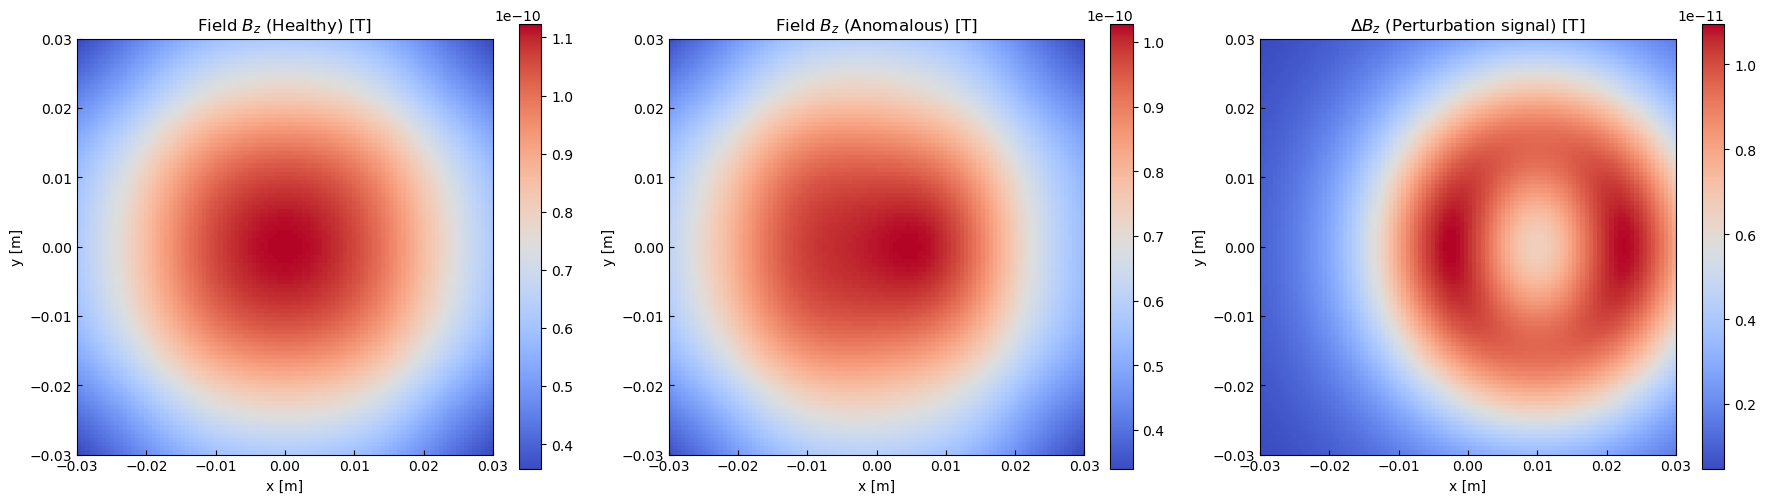

In [33]:
r_rec = 1e-2
Area_pickup = np.pi * (r_rec)**2


Bz_eq_anom = Flux_scan_anom / Area_pickup
Bz_eq_healthy = Flux_scan_healthy / Area_pickup


Bz_eq_diff = Bz_eq_anom - Bz_eq_healthy

np.savetxt("Bz_scan_anom_ges.txt", np.abs(Bz_eq_anom), delimiter = ",", header="Bz_scan anomalous tissue part (T)", comments='')
np.savetxt("Bz_scan_healthy_ges.txt", np.abs(Bz_eq_healthy), delimiter = ",", header="Bz_scan healthy tissue values (T)", comments='')
np.savetxt("Difference_scanned_ges.txt", np.abs(Bz_eq_diff), delimiter = ",", header="Difference Bz (Healthy - Anomalous) (T)", comments='')


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im1 = axes[0].pcolormesh(X, Y, np.abs(Bz_eq_healthy), shading='auto', cmap='coolwarm')
axes[0].set_title("Field $B_z$ (Healthy) [T]")
fig.colorbar(im1, ax=axes[0])

im2 = axes[1].pcolormesh(X, Y, np.abs(Bz_eq_anom), shading='auto', cmap='coolwarm')
axes[1].set_title("Field $B_z$ (Anomalous) [T]")
fig.colorbar(im2, ax=axes[1])

im3 = axes[2].pcolormesh(X, Y, np.abs(Bz_eq_diff), shading='auto', cmap='coolwarm')
axes[2].set_title("$\Delta B_z$ (Perturbation signal) [T]")
fig.colorbar(im3, ax=axes[2])


for ax in axes:
    ax.set_aspect("equal")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.tick_params(direction="in")

plt.tight_layout()
plt.show()